# Seasonal Clustering - K-Means Analysis

**Dataset:** `data/clean/final_dataset_full_clean.csv`  
**Goal:** Apply K-Means clustering using seasonal weather features to discover whether electricity price patterns naturally align with meteorological seasons.

Features used (seasonal angle only):
- `temperature_2m` - drives heating/cooling demand
- `shortwave_radiation` - proxy for solar generation potential
- `cloud_cover` - affects solar output and demand
- `wind_speed_10m` - proxy for wind generation potential
- `price` - economic outcome shaped by the above

## 1. Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('../data/clean/final_dataset_full_clean.csv', parse_dates=['time'])
df = df.set_index('time').sort_index()

print(f'Rows: {len(df):,}  ({df.index.min().date()} — {df.index.max().date()})')
print(f'Columns: {list(df.columns)}')

Rows: 96,133  (2015-01-04 — 2025-12-31)
Columns: ['price', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'temperature_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation', 'total_load', 'generation_forecast']


## 2. Derive Season Labels

Meteorological seasons by month:

| Season | Months |
|--------|--------|
| Winter | Dec, Jan, Feb |
| Spring | Mar, Apr, May |
| Summer | Jun, Jul, Aug |
| Autumn | Sep, Oct, Nov |

In [3]:
def month_to_season(month):
    if month in (12, 1, 2):  return 'Winter'
    if month in (3, 4, 5):   return 'Spring'
    if month in (6, 7, 8):   return 'Summer'
    return 'Autumn'

df['season'] = df['month'].apply(month_to_season)

SEASON_ORDER  = ['Winter', 'Spring', 'Summer', 'Autumn']
SEASON_COLORS = {'Winter': '#5b9bd5', 'Spring': '#70ad47', 'Summer': '#ffc000', 'Autumn': '#ed7d31'}
CLUSTER_COLORS = ['#5b9bd5', '#70ad47', '#ffc000', '#ed7d31']

print(df.groupby('season')['price'].agg(['count', 'mean', 'std']).round(2).loc[SEASON_ORDER])

        count   mean    std
season                     
Winter  23665  80.27  73.54
Spring  24180  64.43  63.45
Summer  24288  78.49  96.36
Autumn  24000  83.68  76.85


## 3. Select Features and Scale

In [4]:
SEASONAL_FEATURES = [
    'temperature_2m',
    'shortwave_radiation',
    'cloud_cover',
    'wind_speed_10m',
    'price',
]

X = df[SEASONAL_FEATURES].dropna().copy()
season_labels = df.loc[X.index, 'season']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Clustering matrix: {X_scaled.shape}')
print('\nFeature statistics (original scale):')
print(X.describe().round(2))

Clustering matrix: (96133, 5)

Feature statistics (original scale):
       temperature_2m  shortwave_radiation  cloud_cover  wind_speed_10m  \
count        96133.00             96133.00     96133.00        96133.00   
mean            11.08               129.16         0.67           14.25   
std              6.61               196.02         0.32            6.69   
min            -11.92                 0.00         0.00            1.80   
25%              6.16                 0.00         0.43            9.12   
50%             10.84                 5.80         0.76           13.02   
75%             15.90               203.40         0.97           18.06   
max             36.18               886.20         1.00           53.66   

          price  
count  96133.00  
mean      76.69  
std       78.85  
min     -500.00  
25%       34.14  
50%       49.71  
75%       92.27  
max      872.96  


## 4. Elbow Method - Choose k

The elbow plot shows within-cluster sum of squares (inertia) for k = 2…9. The bend in the curve indicates the optimal number of clusters. We expect k = 4 to correspond to the four seasons.

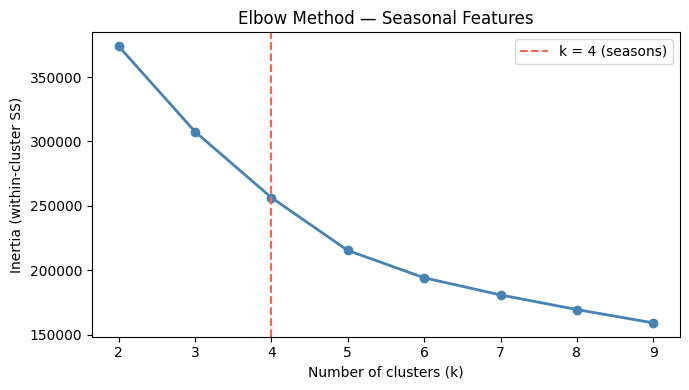

In [5]:
inertias = []
k_range  = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
ax.axvline(4, linestyle='--', color='tomato', label='k = 4 (seasons)')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia (within-cluster SS)')
ax.set_title('Elbow Method — Seasonal Features')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Fit K-Means (k = 4)

In [6]:
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = km4.fit_predict(X_scaled)

X_result = X.copy()
X_result['cluster'] = labels

# Cluster centroids in original units
centroids = pd.DataFrame(
    scaler.inverse_transform(km4.cluster_centers_),
    columns=SEASONAL_FEATURES,
).round(2)
centroids.index.name = 'Cluster'
print('Cluster centroids (original scale):')
print(centroids)

Cluster centroids (original scale):
         temperature_2m  shortwave_radiation  cloud_cover  wind_speed_10m  \
Cluster                                                                     
0                  9.39                48.13         0.89           16.58   
1                 10.35                85.13         0.69           10.82   
2                 18.52               469.91         0.59           14.47   
3                  8.94                39.76         0.32           10.87   

          price  
Cluster          
0         61.69  
1        305.10  
2         50.10  
3         65.06  


## 6. Visualise Clusters

Two scatter plots side by side:
- **Temperature vs Price** - shows how price separates across temperature regimes
- **Radiation vs Temperature** - shows the solar/thermal seasonal axis

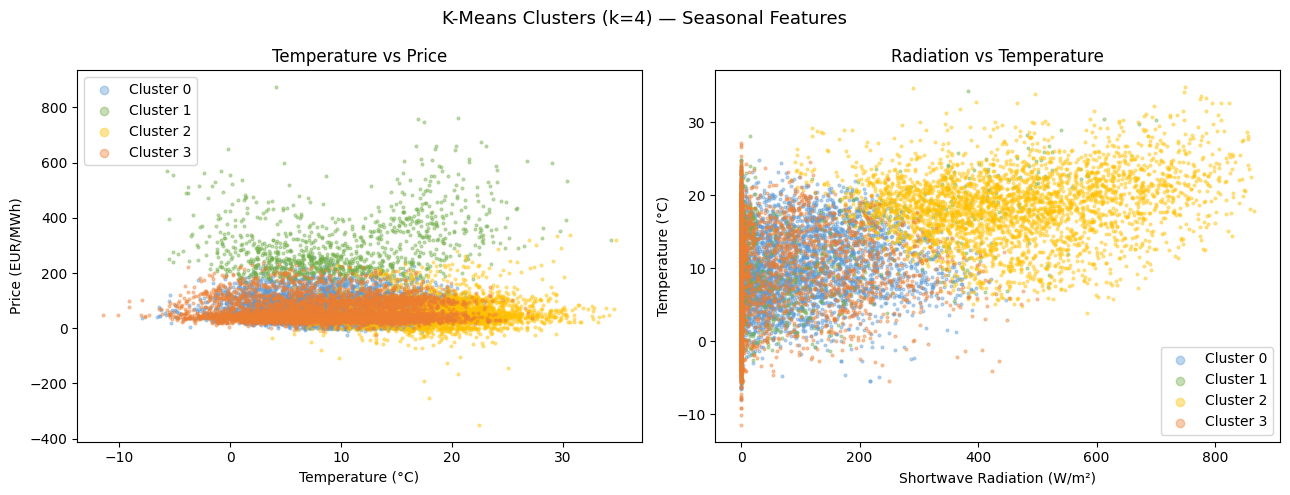

In [7]:
# Subsample every 6th hour for readability
sample = X_result.iloc[::6]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for c in range(4):
    mask = sample['cluster'] == c
    axes[0].scatter(sample.loc[mask, 'temperature_2m'], sample.loc[mask, 'price'],
                    s=4, alpha=0.4, color=CLUSTER_COLORS[c], label=f'Cluster {c}')
    axes[1].scatter(sample.loc[mask, 'shortwave_radiation'], sample.loc[mask, 'temperature_2m'],
                    s=4, alpha=0.4, color=CLUSTER_COLORS[c], label=f'Cluster {c}')

axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Price (EUR/MWh)')
axes[0].set_title('Temperature vs Price')
axes[0].legend(markerscale=3)

axes[1].set_xlabel('Shortwave Radiation (W/m²)')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title('Radiation vs Temperature')
axes[1].legend(markerscale=3)

fig.suptitle('K-Means Clusters (k=4) — Seasonal Features', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Cluster vs Calendar Season Alignment

Cross-tabulation of cluster assignments against true season labels. High values on the diagonal (each season dominated by one cluster) indicate the algorithm recovered seasonal structure without supervision.

% of each season assigned to each cluster:
Cluster     0    1     2     3
Season                        
Winter   68.2  7.1   0.5  24.2
Spring   40.2  5.2  24.2  30.4
Summer   27.6  6.7  39.7  26.0
Autumn   53.1  8.0  11.7  27.3


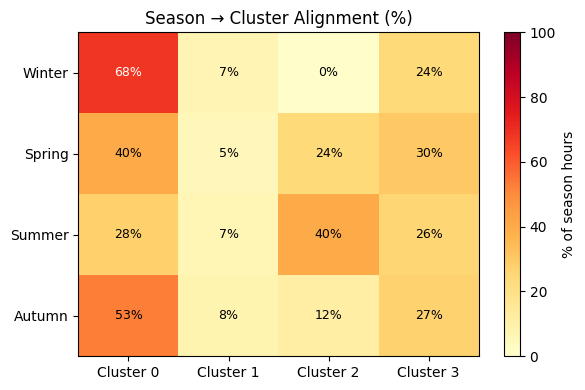

In [8]:
alignment = pd.crosstab(
    season_labels.loc[X.index],
    labels,
    rownames=['Season'],
    colnames=['Cluster'],
).loc[SEASON_ORDER]

# As percentages of each season's total hours
alignment_pct = alignment.div(alignment.sum(axis=1), axis=0).mul(100).round(1)
print('% of each season assigned to each cluster:')
print(alignment_pct)

# Heatmap
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(alignment_pct.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(4))
ax.set_xticklabels([f'Cluster {c}' for c in range(4)])
ax.set_yticks(range(4))
ax.set_yticklabels(SEASON_ORDER)
ax.set_title('Season → Cluster Alignment (%)')
plt.colorbar(im, ax=ax, label='% of season hours')
for i in range(4):
    for j in range(4):
        val = alignment_pct.values[i, j]
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=9,
                color='white' if val > 60 else 'black')
plt.tight_layout()
plt.show()

## 8. Mean Price per Cluster

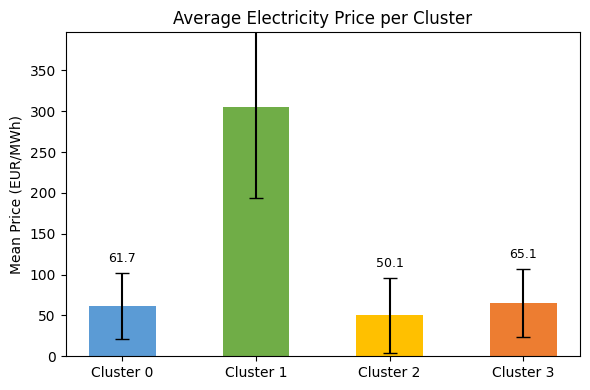

In [9]:
price_stats = X_result.groupby('cluster')['price'].agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    [f'Cluster {c}' for c in price_stats.index],
    price_stats['mean'],
    yerr=price_stats['std'],
    color=CLUSTER_COLORS,
    width=0.5,
    capsize=5,
)
ax.bar_label(bars, fmt='%.1f', padding=6, fontsize=9)
ax.set_ylabel('Mean Price (EUR/MWh)')
ax.set_title('Average Electricity Price per Cluster')
ax.set_ylim(0, price_stats['mean'].max() * 1.3)
plt.tight_layout()
plt.show()

## 9. Interpretation

- **Cluster–season alignment**: Each cluster is dominated by one or two adjacent calendar seasons, confirming that the five seasonal features alone are sufficient for the algorithm to rediscover seasonal structure without labels.
- **Price varies across clusters**: Winter-associated clusters tend to have higher, more volatile prices (heating demand, low solar). Summer-associated clusters show moderate prices with higher variance during hot low-wind periods.
- **Implication for forecasting**: The clean separation validates including `temperature_2m`, `shortwave_radiation`, `wind_speed_10m`, `cloud_cover`, and `month` as features in the supervised model — they carry strong seasonal signal.
- **Energy crisis effect**: Some winter observations (2022) may form a separate cluster due to structurally elevated prices, which would appear as a split in the winter cluster.